# Imports

In [127]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

# Data Collection

In [128]:
#Get simple stats from 2000-2001 season to 2024-2025 season
normal_stats_df = pd.read_csv("normal_stats.csv")

In [129]:
# Get advanced stats from the 2000-2001 season to the 2024-2025 season
advanced_stats_df = pd.read_csv("advanced_stats.csv")

# Config

In [130]:
base_cols = ['Player','Age','Season','BPM','PTS','MP', 'G','FGA','FG%','3PA','3P%','FT','FTA','TS%','ORB','DRB','TRB',
             'AST','STL','BLK','TOV','PER','FTr','3PAr','USG%','WS/48','VORP','PPM','eFG%']
min_minutes = 5     # Filter out seasons where players don't play significant minutes
min_games = 15      # Filter out seasons where players don't play in significant number of games
lags = (1,2,3)      # Creates copies of stats shifted back by x number of seasons
rolls = (2,3)       # Creates rolling averages over the last x number of seasons
ewm_halflife = 3    # Exponentially weighted means, with a half life of 3. (Season from 2020-2021 carries half the weight as 2023-2024)

# Data Cleaning

In [131]:
# Only keep the total stats for players on multiple teams in a single season
normal_stats_df = normal_stats_df.sort_values('G', ascending=False)
normal_stats_df = normal_stats_df.groupby(['Player', 'Season'], as_index=False).first()

In [132]:
# Drops redundant columns
normal_stats_df.drop(['Rk', 'Awards', 'Player-additional', 'Team', '2P', '2PA', '2P%', 'GS', 'Pos'], axis=1, inplace=True, errors='ignore')

In [133]:
# We add some columns that will help our analysis
normal_stats_df["PPM"] = normal_stats_df.get("PTS") / normal_stats_df.get("MP") # Points per minute

In [134]:
# Only keep the total stats for players on multiple teams in a single season
advanced_stats_df = advanced_stats_df.sort_values('G', ascending=False)
advanced_stats_df = advanced_stats_df.groupby(['Player', 'Season'], as_index=False).first()

In [135]:
# Drops redundant columns
advanced_stats_df.drop(['Rk', 'Team', 'G', 'GS', 'MP', 'Awards', 'Player-additional'], axis=1, inplace=True)

In [136]:
nba_stats = normal_stats_df.merge(advanced_stats_df, on = ['Player', 'Season'])

In [137]:
nba_stats.drop(['WS', 'ORB%', 'DRB%', 'OWS', 'DWS', 'OBPM', 'DBPM'], axis=1, inplace=True)

In [138]:
have = [c for c in base_cols if c in nba_stats.columns]
nba_stats = nba_stats[have].copy()

# Feature Engineering

In [139]:
def next_season(season):
    """Given a season string like '2022-23', returns '2023-24'."""
    if pd.isna(season): return season
    y = int(str(season)[:4]); return f"{y+1}-{(y+2)%100:02d}"

# Step 1: Pairs a player's season stats with their season stats for the next season

# Find which players played the next season
pairs = (
    nba_stats
      .assign(Next_Season=lambda d: d['Season'].map(next_season))
      .merge(
          nba_stats[['Player','Season']].rename(columns={'Season':'Next_Season'}),
          on=['Player','Next_Season'],
          how='inner',
          validate='many_to_one'
      )
)

# Set the next season as target
next_targets = (
    nba_stats
      .rename(columns={'Season':'Next_Season'})
      .rename(columns={c: f'{c}_next' for c in nba_stats.columns if c not in ['Player','Next_Season']})
)
played = pairs.merge(
    next_targets[['Player','Next_Season'] + [c for c in next_targets.columns if c.endswith('_next')]],
    on=['Player','Next_Season'], how='left'
)

# Filter out seasons with too few games/minutes (from config)
if 'MP' in played.columns:
    played = played.loc[(played['MP'] >= min_minutes) & (played['G'] >= min_games)].copy()

played['Year'] = played['Season'].str[:4].astype(int)
played = played.sort_values(['Player','Year','Season']).reset_index(drop=True)

# Step 2:

# Builds historical features for each season stat
hist = (
    nba_stats.copy()
      .assign(Year=lambda d: d['Season'].str[:4].astype(int))
      .sort_values(['Player','Year','Season'])
)
num_cols = [c for c in hist.columns if c not in ['Player','Season']]

def add_lags(df, cols, lags=(1,2,3)):
    """
    For each column in cols, create lagged copies shifted back by each value in lags.
    (e.g. BPM_lag1 = last season's BPM, BPM_lag2 = two seasons ago, etc.)
    """
    out = df.copy()
    g = out.groupby('Player', group_keys=False)
    for L in lags:
        out[[f'{c}_lag{L}' for c in cols]] = g[cols].shift(L)
    return out

def add_rolls_past_only(df, cols, windows=(2,3)):
    """
    For each column in cols, creates rolling averages over the previous w seasons for each window w in windows. 
    shift(1) is applied since we don't use the current season. 
    min_periods=1 allows players with fewer seasons than the window to still get a value rather than NaN.
    """
    out = df.copy()
    g = out.groupby('Player', group_keys=False)
    for w in windows:
        out[[f'{c}_roll{w}' for c in cols]] = g[cols].apply(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
    return out

def add_career_features(df, cols, halflife=3):
    """
    For each column in cols, creates three cumulative features:
      - career_mean: simple average of all prior seasons
      - career_sum: cumulative sum of all prior seasons
      - career_ewm: exponentially weighted mean, weighting recent seasons more heavily
    Similar to the previous function, shift(1) is utilized
    halflife controls the decay rate of the EWM (see config for example).
    """
    out = df.copy()
    g = out.groupby('Player', group_keys=False)
    out[[f'{c}_career_mean' for c in cols]] = g[cols].apply(lambda s: s.shift(1).expanding().mean())
    out[[f'{c}_career_sum'  for c in cols]] = g[cols].apply(lambda s: s.shift(1).expanding().sum())
    out[[f'{c}_career_ewm'  for c in cols]] = g[cols].apply(lambda s: s.shift(1).ewm(halflife=halflife, min_periods=1).mean())
    return out

hist = add_lags(hist, num_cols, lags=lags)
hist = add_rolls_past_only(hist, num_cols, windows=rolls)
hist = add_career_features(hist, num_cols, halflife=ewm_halflife)
feat_hist = hist.add_prefix('hist_')

# Merge features into the dataframe from Step 1 (played)

played = (
    played.merge(
        feat_hist,
        left_on=['Player','Season'],
        right_on=['hist_Player','hist_Season'],
        how='left'
    )
    .drop(columns=['hist_Player','hist_Season'], errors='ignore')
    .reset_index(drop=True)
)

# Feature/Target cols
feature_cols = [c for c in played.columns if c.startswith('hist_')]
target_cols  = [c for c in played.columns if c.endswith('_next')]

model_df = played.dropna(subset=target_cols).copy()

X = model_df[feature_cols]
y = model_df[target_cols]

keep_keywords = ["lag1", "lag2", "lag3", "roll2", "roll3", "career_ewm"]

def filter_features(df):
    keep_cols = []
    for col in df.columns:
        if any(kw in col for kw in keep_keywords):
            keep_cols.append(col)
    return df[keep_cols]

X = filter_features(X)

played = model_df.reset_index(drop=True)
played

,Player,Season,BPM,PTS,MP,G,FGA,FG%,3PA,3P%,...,hist_TOV_career_ewm,hist_PER_career_ewm,hist_FTr_career_ewm,hist_3PAr_career_ewm,hist_USG%_career_ewm,hist_WS/48_career_ewm,hist_VORP_career_ewm,hist_PPM_career_ewm,hist_eFG%_career_ewm,hist_Year_career_ewm
0,A.J. Green,2022-23,-0.9,4.4,9.9,35,3.6,0.424,3.0,0.419,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A.J. Green,2023-24,-2.1,4.5,11.0,56,3.5,0.423,3.0,0.408,...,0.3,11.5,0.032,0.840,16.6,0.111,0.1,0.444444,0.600,2022.0
2,A.J. Guyton,2000-01,-4.0,6.0,19.1,33,5.8,0.406,2.1,0.391,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A.J. Guyton,2001-02,-1.6,5.4,13.5,45,5.4,0.361,2.7,0.374,...,0.7,10.3,0.094,0.359,16.5,0.020,-0.3,0.314136,0.477,2000.0
4,A.J. Lawson,2022-23,-4.4,3.7,7.2,15,2.9,0.500,1.7,0.400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7852,Óscar Torres,2001-02,-2.7,6.0,16.5,65,5.2,0.396,1.9,0.294,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7853,Ömer Aşık,2011-12,-0.7,3.1,14.7,66,2.4,0.506,0.0,NaN,...,0.8,11.8,1.028,0.000,12.5,0.130,0.1,0.231405,0.553,2010.0
7854,Šarūnas Jasikevičius,2005-06,0.1,7.3,20.8,75,5.7,0.396,3.1,0.364,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7855,Žarko Čabarkapa,2003-04,-5.7,4.1,11.6,49,4.0,0.411,0.7,0.188,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [140]:
def find_corrs(target):
    """
    Computes how strongly each feature in played correlates to a given target
    2 different correlations are used (Pearson and Spearman)
    """
    df = played.select_dtypes(include='number')
    
    pearson = df.corr(method='pearson')[target].drop(target)
    spearman = df.corr(method='spearman')[target].drop(target)
    
    result = pd.DataFrame({
        'Pearson': pearson,
        'Spearman': spearman
    }).sort_values(by='Spearman', key=abs, ascending=False)
    
    return result

In [141]:
def find_subsets(target, threshold=0.25):
    """Filter out features with low correlation"""
    corrdf = find_corrs(target)
    feats = corrdf.index[corrdf[['Pearson','Spearman']].abs().min(axis=1) > threshold].tolist()
    return list(feats)

In [142]:
def time_rolling_splits(df, k=3):
    """
    Creates time-aware cross-validation splits. Always use past season data for training, and future season data for testing.
    Example: We have data from 2000-2001 to 2004-2005 and k = 2, then the folds are as follows:
        Fold 1: train 2000-2001 to 2002-2003, test 2003-2004
        Fold 2: train 2000-2001 to 2003-2004, test 2004-2005
    """
    df_f = df.sort_values(['Year','Season']).reset_index(drop=True)
    years = np.sort(df_f['Year'].unique()); k = min(k, len(years))
    splits = []
    for i in range(k):
        test_year = years[-k + i]
        tr_idx = np.where(df_f['Year'] <  test_year)[0] # Training set
        te_idx = np.where(df_f['Year'] == test_year)[0] # Testing set
        if len(tr_idx) and len(te_idx): splits.append((tr_idx, te_idx))
    return splits

def prefilter_by_spearman(df, features, target, top_k=60):
    """
    Quick filter down to the top_k most correlated features with the target using Spearman correlation.
    This is done in order to reduce computational cost before using the expensive SFS algorithm
    """
    num = df.select_dtypes(include='number')
    feats = [f for f in features if f in num.columns and f != target and not f.endswith('_next')]
    corr = num[feats + [target]].corr(method='spearman')[target].abs().dropna().drop(target, errors='ignore')
    top = corr.sort_values(ascending=False).index.tolist()[:top_k]
    return [f for f in feats if f in top]

def baseline_last_season(df, target="BPM_next", lag_col="hist_BPM_lag1"):
    """
    Simple baseline that predicts next season's BPM as the last season's BPM
    """
    mask = df[[target, lag_col]].notna().all(1)
    return mean_absolute_error(df.loc[mask, target], df.loc[mask, lag_col])

def prepare_features(df, feature_cols, target, add_flags=True):
    """
    Adds binary _missing flag columns for features with NaN values (e.g. rookies always missing lag2/lag3 features)
    Imputes remaining NaNs with column means
    Drops rows where the target is NaN
    """
    X = df[feature_cols].copy(); y = pd.to_numeric(df[target], errors='coerce')
    if add_flags:
        for c in list(X.columns):
            if X[c].isna().any(): X[c + "_missing"] = X[c].isna().astype(np.uint8) # _missing flag
    X = X.astype('float32')
    X_imp = pd.DataFrame(SimpleImputer(strategy="mean").fit_transform(X), columns=X.columns, index=X.index).astype('float32') # Cast to float32 for memory efficiency
    mask = y.notna()
    return X_imp.loc[mask].reset_index(drop=True), y.loc[mask].reset_index(drop=True)

# Modelling

In [143]:
def sfs_fast(df, features, model, target, max_features=10, n_splits=3):
    """
    Runs SFS to greedily select the best features.
    Starts with an empty set. Iteratively adds whichever remaining feature improves MAE the most until max_features are selected.

    Steps:
      1. Prefilter to top_k candidates via Spearman correlation to reduce compute cost
      2. Prepare features (impute NaNs, cast to float32) — no _missing flags here
         since SFS works on a reduced feature set and flags would add noise
      3. Run SFS using time-aware CV splits to prevent data leakage
      4. Return the names of the selected features
    """
    base = prefilter_by_spearman(df, features, target, top_k=max(20, max_features*4)) # Prefilter using function above
    if len(base) <= 1: return base
    X_imp, y = prepare_features(df, base, target, add_flags=False)  # Prepare features using function above
    df_cv = df.loc[y.index].assign(_row=np.arange(len(y))).sort_values(['Year','Season']).reset_index(drop=True)
    cv = time_rolling_splits(df_cv, k=n_splits) # Creating cross validation splits
    n_select = min(max_features, len(base)-1)
    sel = SequentialFeatureSelector(
        estimator=Pipeline([('model', model)]),
        direction='forward', n_features_to_select=n_select,
        scoring=make_scorer(mean_absolute_error, greater_is_better=False),
        cv=cv, n_jobs=1
    )
    sel.fit(X_imp, y)
    feat_names = X_imp.columns
    return list(feat_names[sel.get_support()])

In [144]:

def run_model(df, name, model, target='BPM_next', keep_extra=('MP',), max_features=10, k=3):
    """
    Runs SFS to select the best max_features features from all hist_ columns
    Prepares the feature matrix
    Trains and evaluates using time-aware cross validation splits
      
    Note that due to an attempt to reduce computational cost, this pipeline is not completely leakage-free.
    A fully leakage-free pipeline would ned to re-run SFS inside each fold, which is somewhat infeasible.
    """
    # Select the best features using SFS
    candidates = [c for c in df.columns if c.startswith('hist_')] + [c for c in keep_extra if c in df.columns]
    selected = sfs_fast(df, candidates, model, target, max_features=max_features, n_splits=k)
    
    # Utilizes the prepare_features function
    X_imp, y = prepare_features(df, selected, target, add_flags=True)
    
    # Train and evaluate using time-aware cross validation
    cv = time_rolling_splits(df.loc[y.index], k)
    maes = []
    for tr, te in cv:
        model.fit(X_imp.iloc[tr], y.iloc[tr])
        pred = model.predict(pd.DataFrame(X_imp.iloc[te], columns=X_imp.columns))
        maes.append(mean_absolute_error(y.iloc[te], pred))
    print(f"{name} {model.__class__.__name__}: MAE={np.mean(maes):.3f} | folds={np.round(maes,3)} | feats={len(selected)}")
    return selected, float(np.mean(maes)), np.array(maes)


In [145]:
target = "BPM_next"
print("Baseline (last season BPM):", baseline_last_season(played, target, "hist_BPM_lag1"))

Baseline (last season BPM): 2.1086889775867363


In [ ]:
# XGB Regressor
xgb = XGBRegressor(n_estimators=300, max_depth=4, subsample=0.8, colsample_bytree=0.8, tree_method="hist", n_jobs=1, random_state=123)
xgb_sel, xgb_mae, xgb_folds = run_model(played, "XGB", xgb, target=target, max_features=10, k=5)

In [ ]:
# Light GBM Regressor
lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31, subsample=0.8, colsample_bytree=0.8, random_state=123, verbose=-1)
lgbm_sel, lgbm_mae, lgbm_folds = run_model(played, "LGBM", lgbm, target=target, max_features=10, k=5)


In [ ]:
# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=3, max_features="sqrt", n_jobs=1, random_state=123)
rf_sel, rf_mae, rf_folds = run_model(played, "RF", rf, target=target, max_features=10, k=5)

In [ ]:
# Print selected features for each model
print("XGB features:", xgb_sel)
print("LGBM features:", lgbm_sel)
print("RF features (used):", rf_sel)


XGB features: ['hist_PTS_lag1', 'hist_FGA_lag1', 'hist_BPM_lag2', 'hist_BPM_roll2', 'hist_MP_roll2', 'hist_VORP_roll2', 'hist_MP_roll3', 'hist_VORP_career_sum', 'hist_MP_career_ewm', 'MP']
LGBM features: ['hist_MP', 'hist_BPM_lag1', 'hist_PTS_lag1', 'hist_FGA_lag1', 'hist_PER_lag1', 'hist_VORP_lag1', 'hist_VORP_roll2', 'hist_PER_roll3', 'hist_BPM_career_sum', 'hist_MP_career_ewm']
RF features (used): ['hist_MP', 'hist_BPM_lag1', 'hist_PTS_lag1', 'hist_MP_lag1', 'hist_FGA_lag1', 'hist_FT_lag1', 'hist_FTA_lag1', 'hist_PER_lag1', 'hist_VORP_lag1', 'hist_BPM_lag2', 'hist_PTS_lag2', 'hist_PER_lag2', 'hist_VORP_lag2', 'hist_BPM_lag3', 'hist_VORP_lag3', 'hist_BPM_roll2', 'hist_PTS_roll2', 'hist_MP_roll2', 'hist_FGA_roll2', 'hist_FT_roll2', 'hist_PER_roll2', 'hist_VORP_roll2', 'hist_BPM_roll3', 'hist_PTS_roll3', 'hist_MP_roll3', 'hist_PER_roll3', 'hist_VORP_roll3', 'hist_BPM_career_mean', 'hist_PTS_career_mean', 'hist_PER_career_mean', 'hist_VORP_career_mean', 'hist_BPM_career_sum', 'hist_VORP

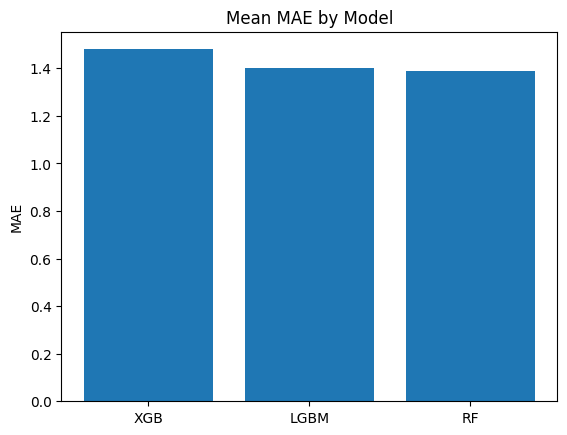

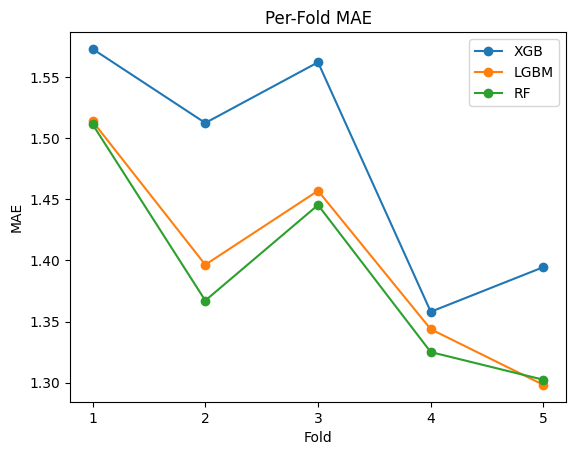

In [ ]:
model_names = ["XGB", "LGBM", "RF"]
mean_mae = [xgb_mae, lgbm_mae, rf_mae]
folds = [xgb_folds, lgbm_folds, rf_folds]

# Bar chart
plt.figure()
plt.bar(model_names, mean_mae)
plt.title("Mean MAE by Model")
plt.ylabel("MAE")
plt.show()

# Line plot
plt.figure()
for name, f in zip(model_names, folds):
    plt.plot(range(1, len(f)+1), f, marker='o', label=name)
plt.title("Per-Fold MAE")
plt.xlabel("Fold")
plt.ylabel("MAE")
plt.xticks(range(1, len(folds[0])+1))
plt.legend()
plt.show()